In [1]:
# 1.Load a dataset with several numeric columns, for example the wine dataset built into scikit learn, and set the label column aside so the model never sees it.
# 2.Scale the numeric features first, because K Means measures distance and is therefore just as sensitive to scale as KNN was on Day 12.
import os
os.environ["OMP_NUM_THREADS"] = "1"
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
wine=load_wine()
x=wine.data
y=wine.target
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
kmeans=KMeans(n_clusters=3,random_state=42,n_init=10)
kmeans.fit(x_scaled)
cluster=kmeans.labels_
print("First 20 Cluster Assignments")
print(cluster[:20])
print("Cluster Centres")
print(kmeans.cluster_centers_)
print("Inertia")
print(kmeans.inertia_)

First 20 Cluster Assignments
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
Cluster Centres
[[-0.92607185 -0.39404154 -0.49451676  0.17060184 -0.49171185 -0.07598265
   0.02081257 -0.03353357  0.0582655  -0.90191402  0.46180361  0.27076419
  -0.75384618]
 [ 0.16490746  0.87154706  0.18689833  0.52436746 -0.07547277 -0.97933029
  -1.21524764  0.72606354 -0.77970639  0.94153874 -1.16478865 -1.29241163
  -0.40708796]
 [ 0.83523208 -0.30380968  0.36470604 -0.61019129  0.5775868   0.88523736
   0.97781956 -0.56208965  0.58028658  0.17106348  0.47398365  0.77924711
   1.12518529]]
Inertia
1277.928488844643


In [2]:
#3.	Fit K Means for every number of clusters from two up to ten and record the inertia each time.
inertias=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(x_scaled)
    inertias.append(kmeans.inertia_)
print(inertias)
    

[1658.758852429096, 1277.928488844643, 1175.4283331033473, 1109.5127392938246, 1046.002333214364, 981.5952326111659, 935.2012114738552, 889.8929111933174, 845.8952366525515]


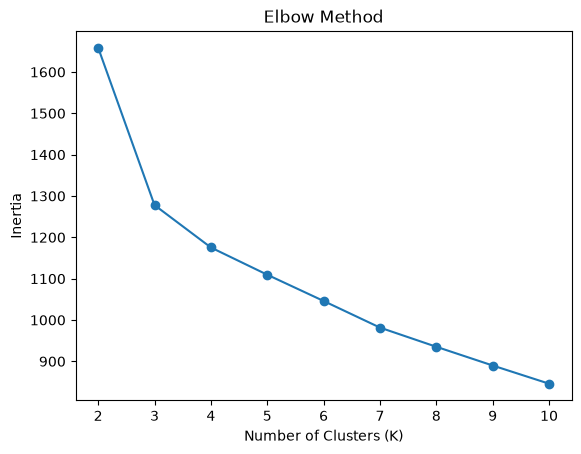

K: 3 Silhouette Scores 0.2848589191898987
K: 4 Silhouette Scores 0.26017035223704527
K: 5 Silhouette Scores 0.20161908294074093


In [3]:
#4.	Plot inertia against the number of clusters, find the bend, then compute the silhouette score for your best two or three candidates
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
plt.plot(range(2,11),inertias,marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()
silhouette_scores = []
for k in [3,4,5]:
    kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    cluster_labels=kmeans.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, cluster_labels)
    silhouette_scores.append(score)
    print("K:",k,"Silhouette Scores",score)
        
    

In [4]:
#5.	Fit the final model with your chosen number of clusters, attach the cluster number back onto the dataframe, and use groupby to describe the average row inside each cluster.
import pandas as pd
kmeans_final=KMeans(n_clusters=3,random_state=42,n_init=10)
kmeans_final.fit(x_scaled)
cluster=kmeans_final.labels_
df=pd.DataFrame(x,columns=wine.feature_names)
df["cluster"]=cluster
cluster_summary = df.groupby("cluster").mean()
print(cluster_summary)


           alcohol  malic_acid       ash  alcalinity_of_ash   magnesium  \
cluster                                                                   
0        12.250923    1.897385  2.231231          20.063077   92.738462   
1        13.134118    3.307255  2.417647          21.241176   98.666667   
2        13.676774    1.997903  2.466290          17.462903  107.967742   

         total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
cluster                                                                     
0             2.247692    2.050000              0.357692         1.624154   
1             1.683922    0.818824              0.451961         1.145882   
2             2.847581    3.003226              0.292097         1.922097   

         color_intensity       hue  od280/od315_of_diluted_wines      proline  
cluster                                                                        
0               2.973077  1.062708                      2.803385   510.169231 